## 1. Importing the required libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

from xgboost import XGBRegressor

## 2. Configurations to use in the file

In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.2

DATASET_PATH = "./energy_consumption_prediction.csv"

TARGET_COLUMN = "energy_consumption"

## 3. Loading the Dataset

In [3]:
df = pd.read_csv(DATASET_PATH)

## 4. Understanding the dataset / Dataset overview

In [4]:
df.shape

(12000, 13)

In [5]:
df.columns

Index(['building_size', 'num_occupants', 'num_appliances', 'outside_temp',
       'inside_temp', 'humidity', 'hour_of_day', 'day_of_week', 'is_weekend',
       'solar_radiation', 'wind_speed', 'insulation_quality',
       'energy_consumption'],
      dtype='str')

In [6]:
df.head()

,building_size,num_occupants,num_appliances,outside_temp,inside_temp,humidity,hour_of_day,day_of_week,is_weekend,solar_radiation,wind_speed,insulation_quality,energy_consumption
0,218.543053,20,34,10.118400,16.748231,76.732400,16,3,0,421.441447,18.009614,1.135626,329.541273
1,477.821438,39,8,-8.931946,29.886419,82.655129,21,6,1,386.235564,17.850043,1.064549,697.615641
2,379.397274,3,17,20.507152,21.936702,53.757046,0,2,0,949.145007,2.739965,0.706921,182.672731
3,319.396318,5,11,11.157176,28.983132,59.486001,15,1,0,386.781356,8.788459,1.365705,242.720456
4,120.208388,1,42,35.988232,26.139800,73.941266,8,2,0,78.477837,10.317220,0.710920,74.599593


In [7]:
df.isnull().sum()

building_size         0
num_occupants         0
num_appliances        0
outside_temp          0
inside_temp           0
humidity              0
hour_of_day           0
day_of_week           0
is_weekend            0
solar_radiation       0
wind_speed            0
insulation_quality    0
energy_consumption    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   building_size       12000 non-null  float64
 1   num_occupants       12000 non-null  int64  
 2   num_appliances      12000 non-null  int64  
 3   outside_temp        12000 non-null  float64
 4   inside_temp         12000 non-null  float64
 5   humidity            12000 non-null  float64
 6   hour_of_day         12000 non-null  int64  
 7   day_of_week         12000 non-null  int64  
 8   is_weekend          12000 non-null  int64  
 9   solar_radiation     12000 non-null  float64
 10  wind_speed          12000 non-null  float64
 11  insulation_quality  12000 non-null  float64
 12  energy_consumption  12000 non-null  float64
dtypes: float64(8), int64(5)
memory usage: 1.2 MB


In [10]:
df.describe()

,building_size,num_occupants,num_appliances,outside_temp,inside_temp,humidity,hour_of_day,day_of_week,is_weekend,solar_radiation,wind_speed,insulation_quality,energy_consumption
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,273.220207,24.975333,27.093250,14.916284,22.976451,55.062486,11.482250,2.985167,0.287667,499.320109,9.937983,1.001377,302.729756
std,129.717114,14.206772,12.920583,14.416455,4.046613,20.181999,6.948048,2.010709,0.452694,290.627618,5.761653,0.289470,179.234909
min,50.005236,1.000000,5.000000,-9.999723,16.000234,20.000590,0.000000,0.000000,0.000000,0.128825,0.000587,0.500028,-323.058724
25%,161.120809,13.000000,16.000000,2.392868,19.443818,37.882751,5.000000,1.000000,0.000000,244.591971,4.904865,0.748767,177.408248
50%,272.262694,25.000000,27.000000,14.943124,22.963667,54.978409,11.000000,3.000000,0.000000,500.788730,10.021270,1.001156,302.339948
75%,385.017146,37.000000,38.000000,27.337593,26.503229,72.673278,18.000000,5.000000,1.000000,755.327494,14.868879,1.255325,429.263013
max,499.872953,49.000000,49.000000,39.989469,29.999610,89.995779,23.000000,6.000000,1.000000,999.992042,19.999519,1.499775,945.220295


In [15]:
df['energy_consumption'].quantile(0.99)

np.float64(702.4829996769505)

There is a huge variance even in the range of 99% to 100% value in the energy_consumption this means that there is high difference in the overall range of values

## 5. Defining feature lists

In [17]:
dfcopy = df.copy()

numerical_columns = dfcopy.select_dtypes(include='number')

target_column = TARGET_COLUMN

categorical_column = dfcopy.select_dtypes(include="str")

## 6. Outlier analysis

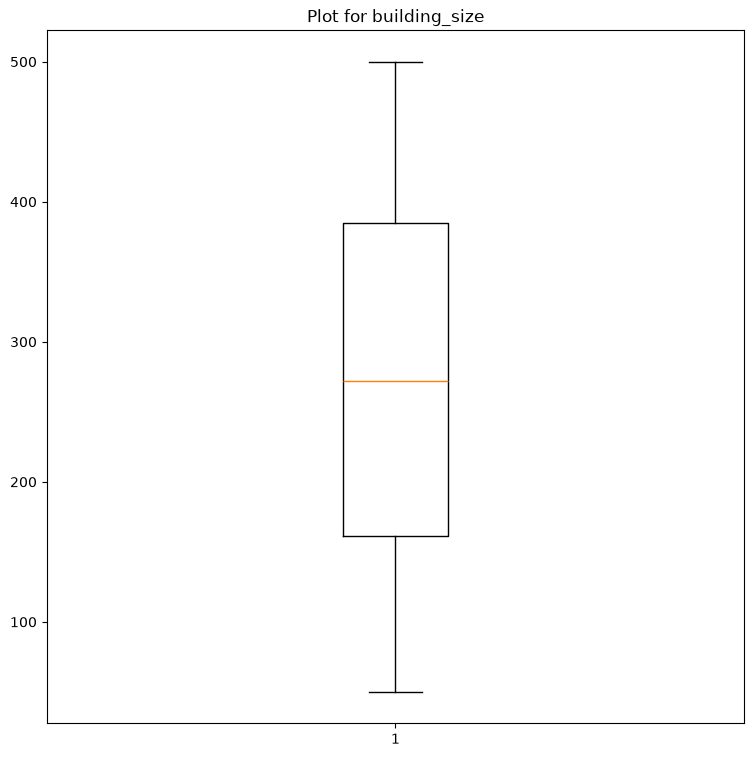

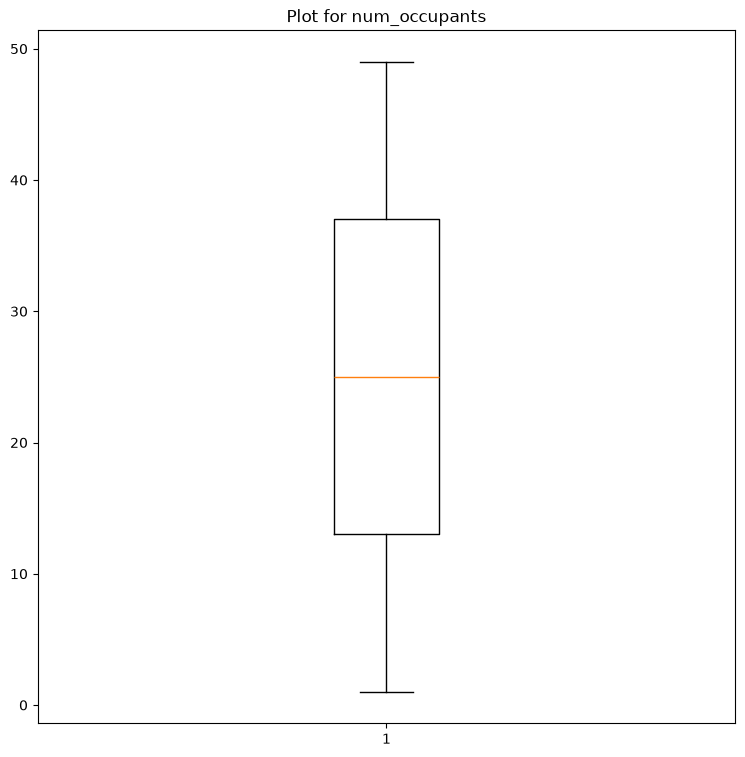

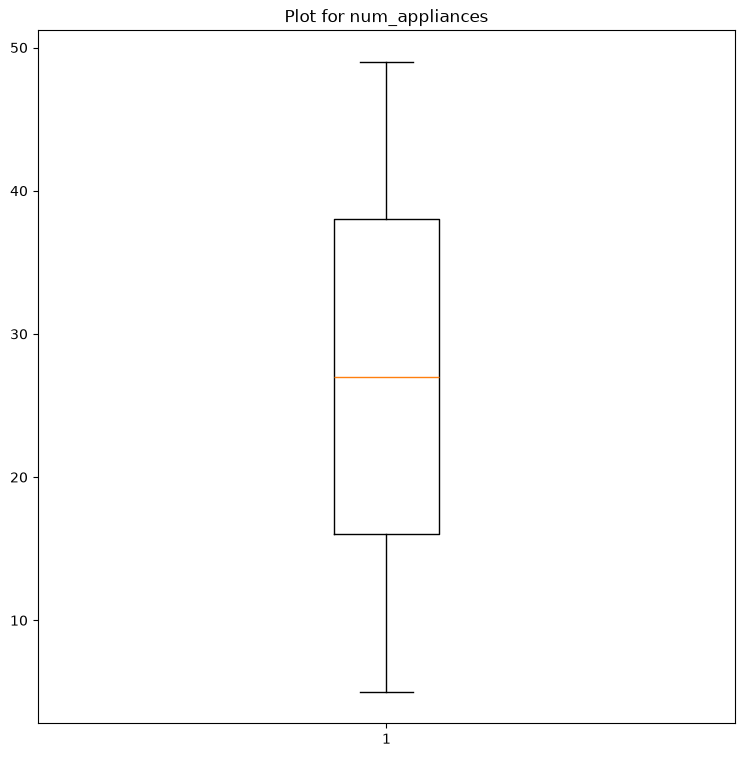

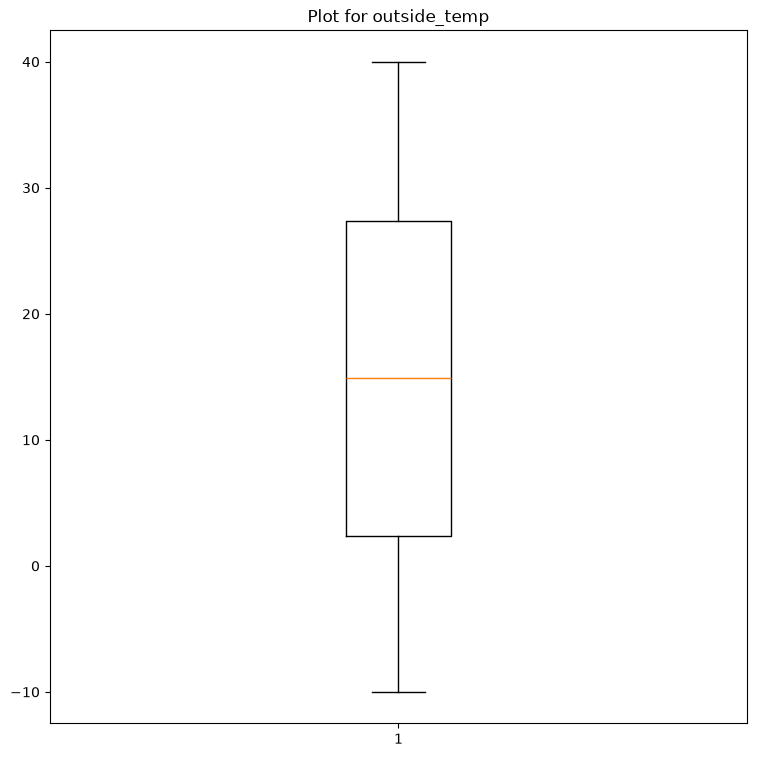

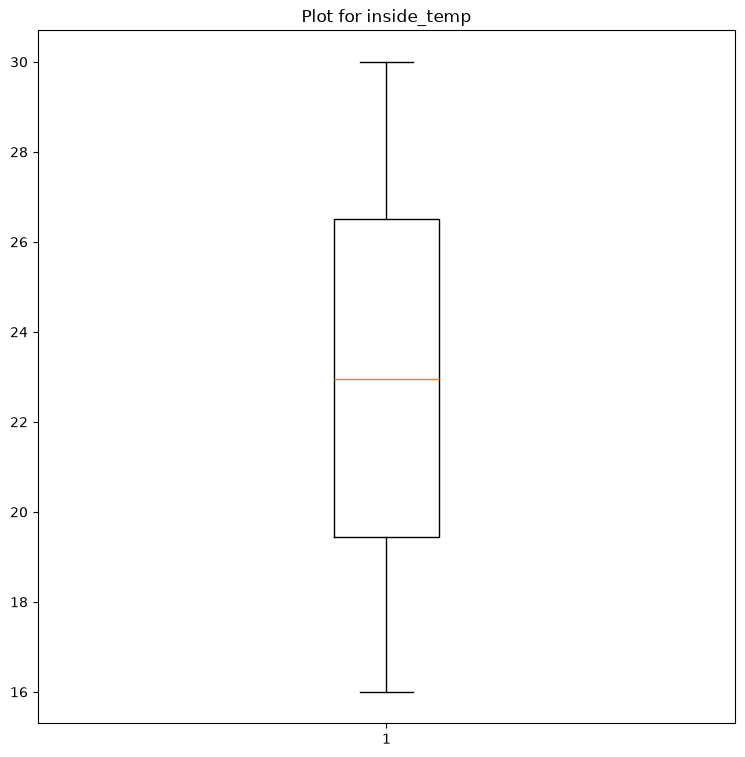

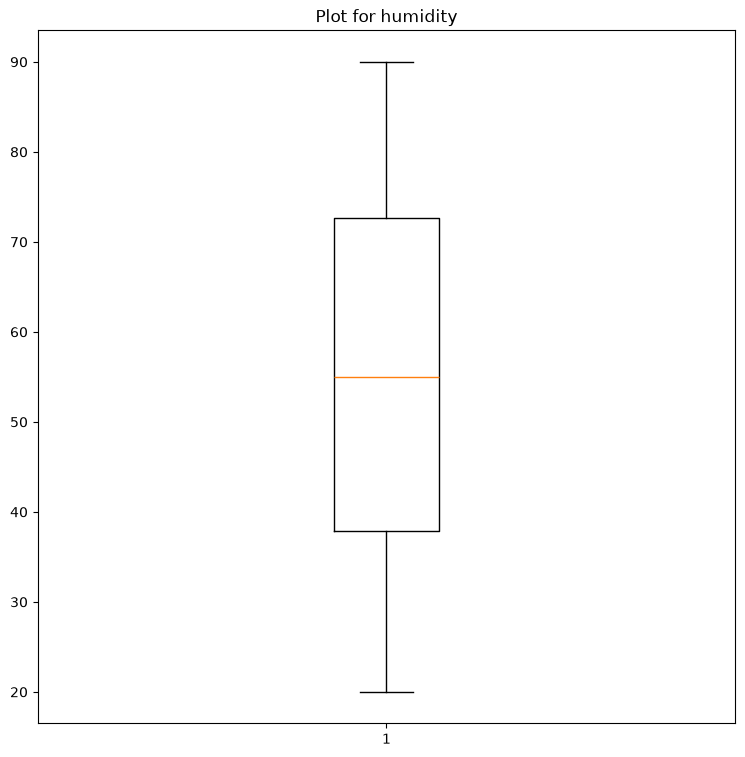

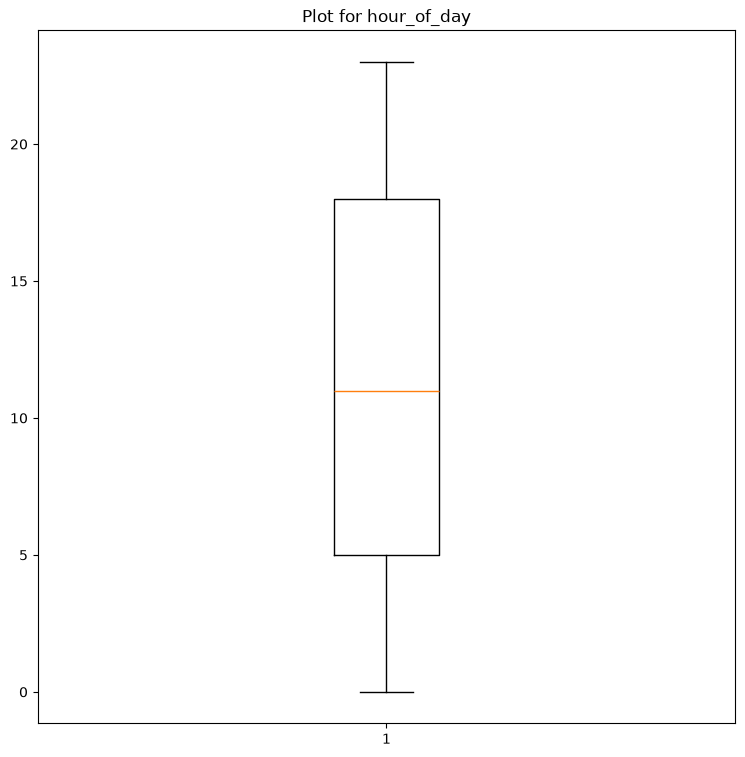

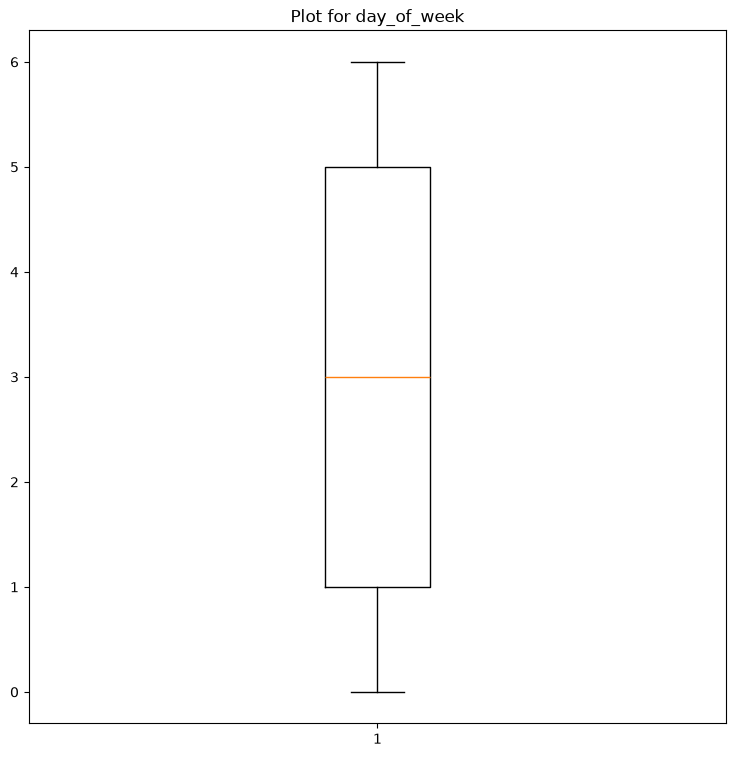

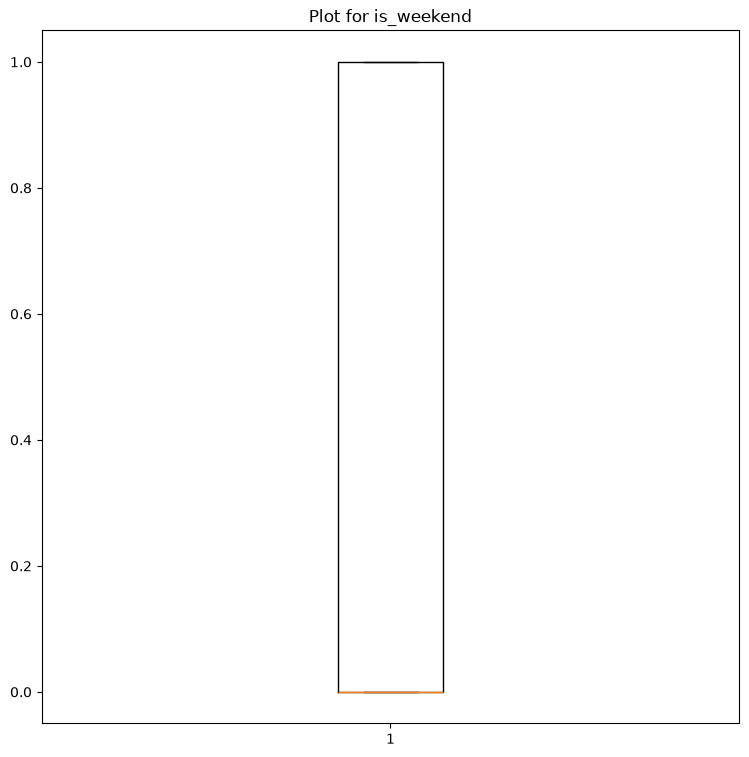

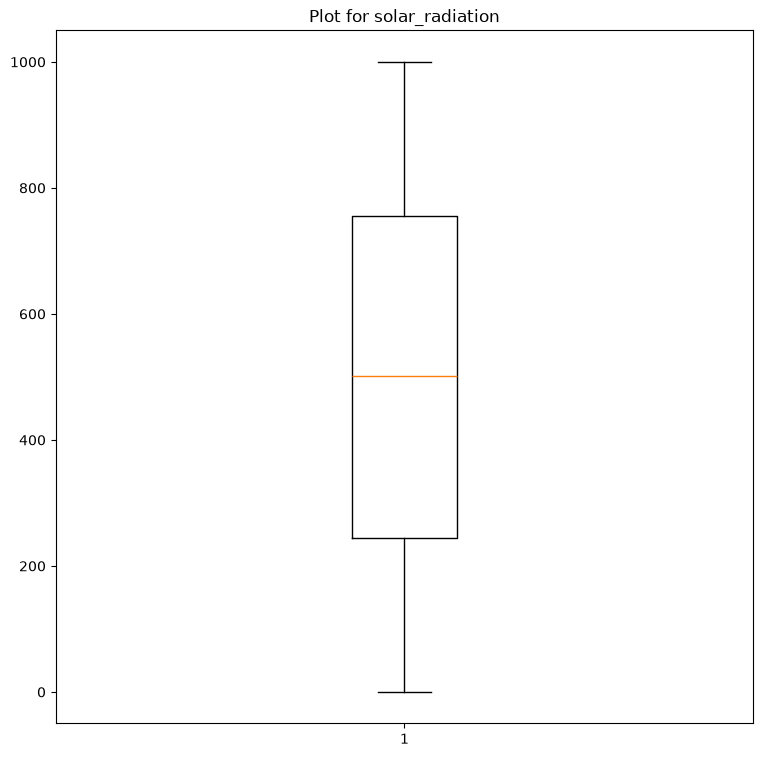

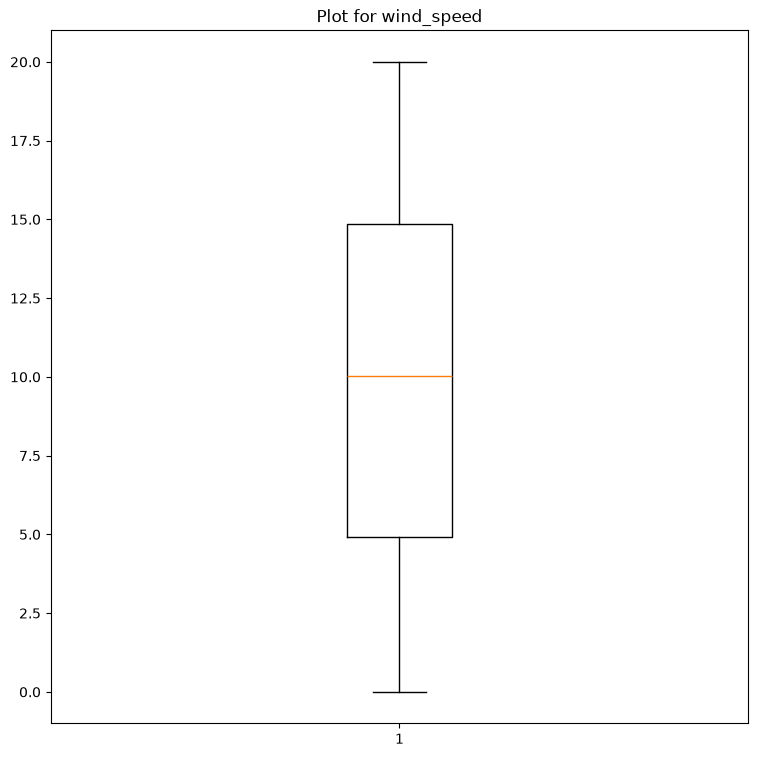

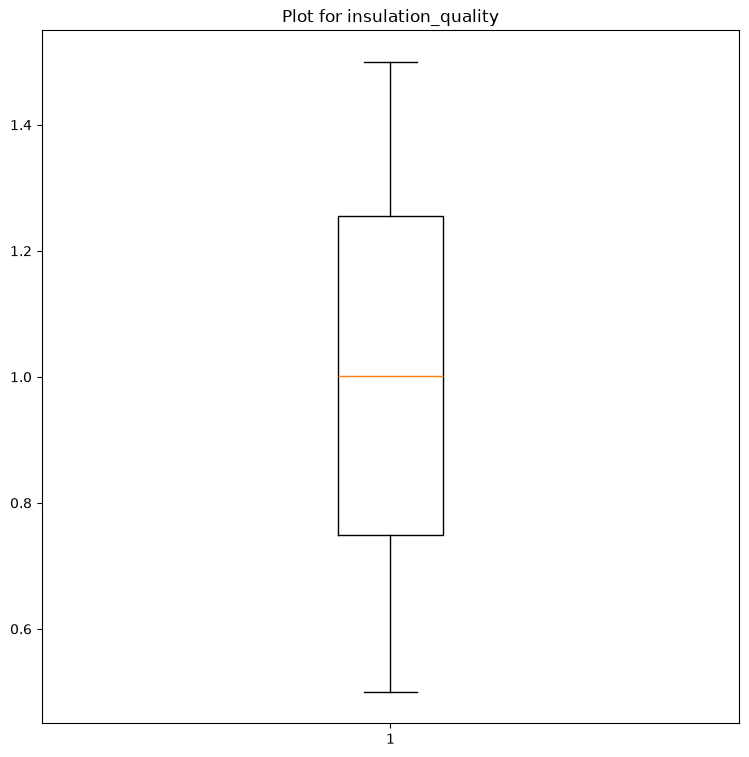

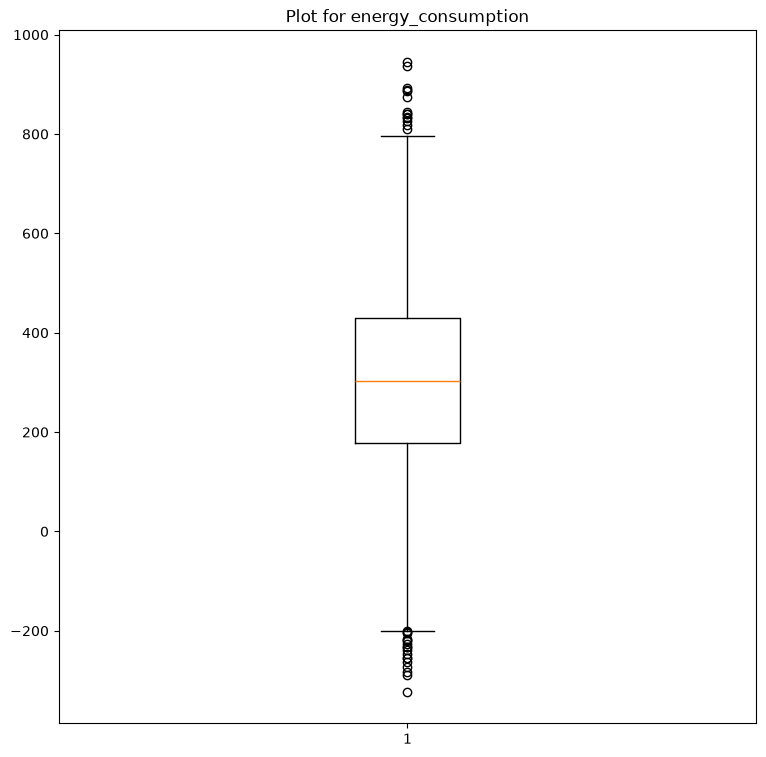

In [18]:
for col in numerical_columns:
    plt.figure(figsize=(9,9))
    plt.boxplot(x=dfcopy[col])
    plt.title(f"Plot for {col}")
    plt.show()

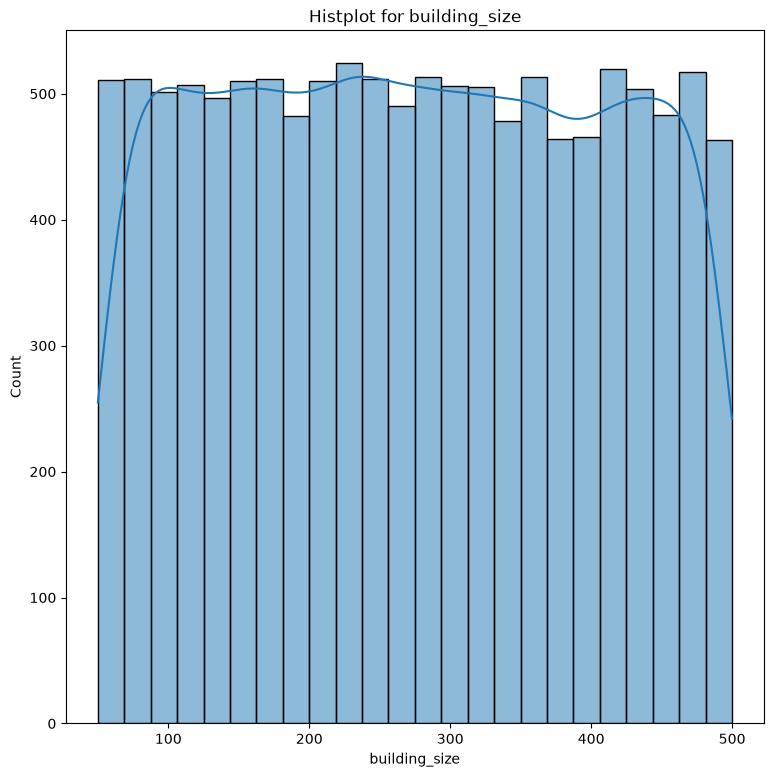

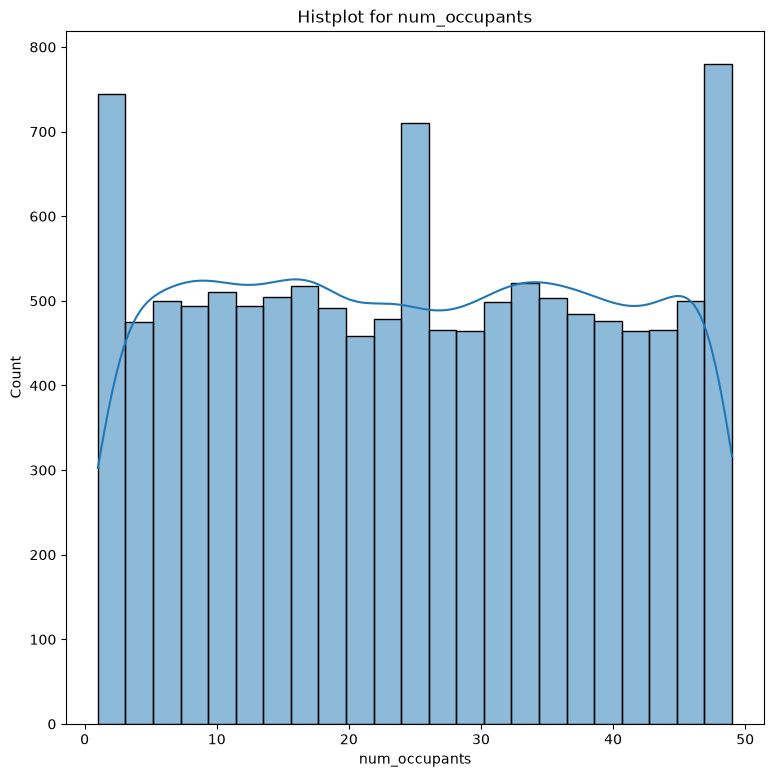

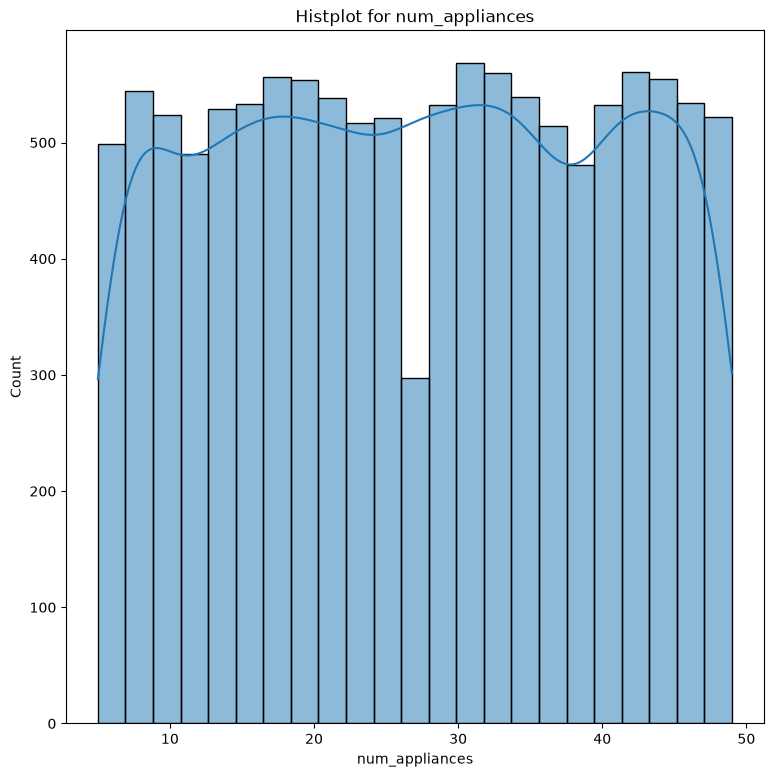

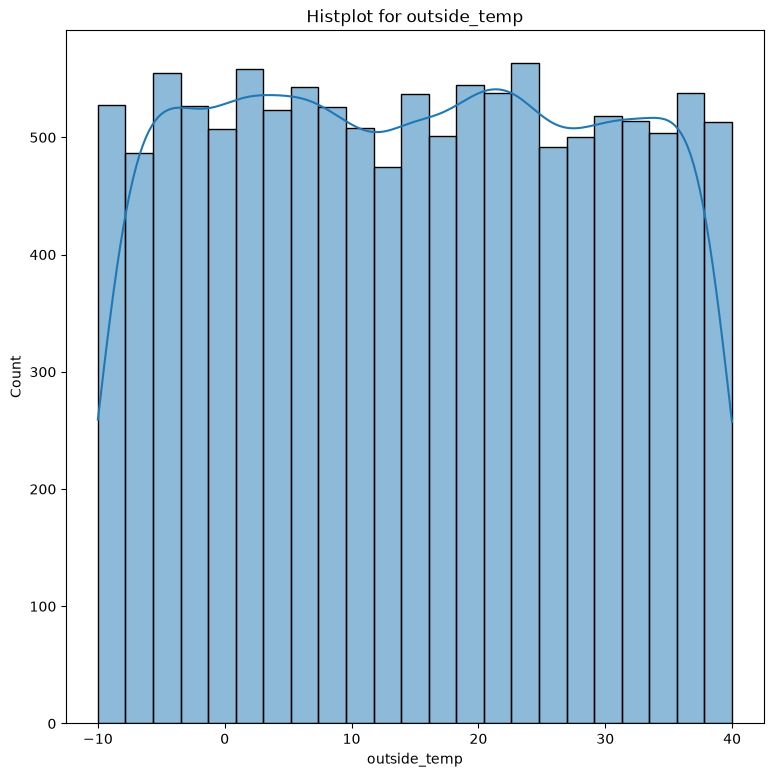

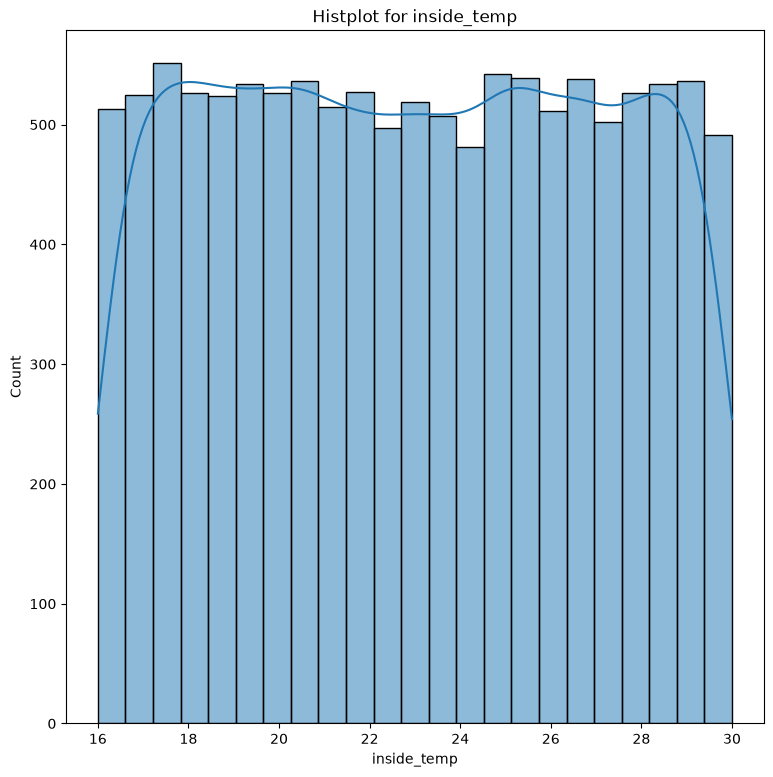

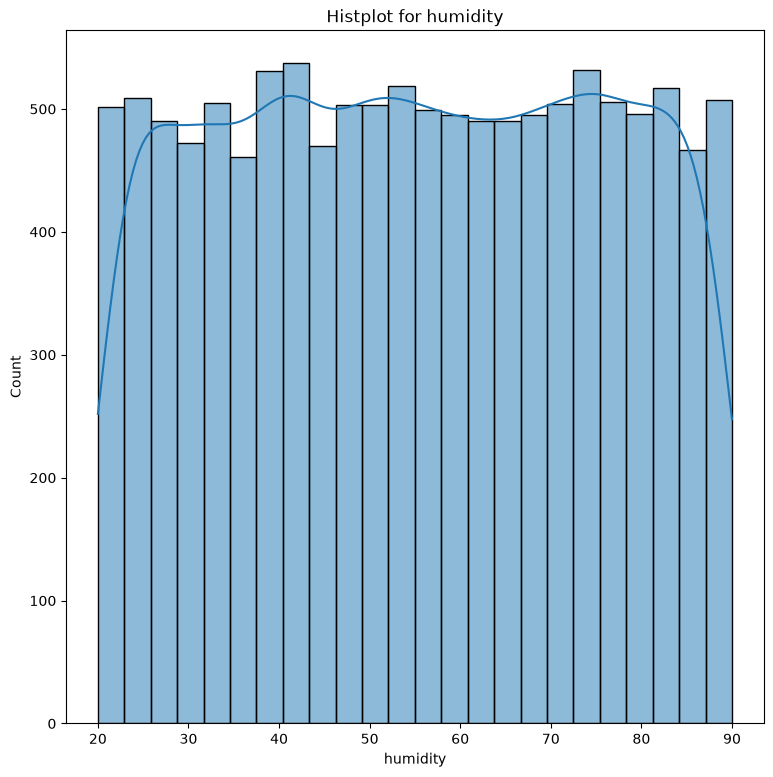

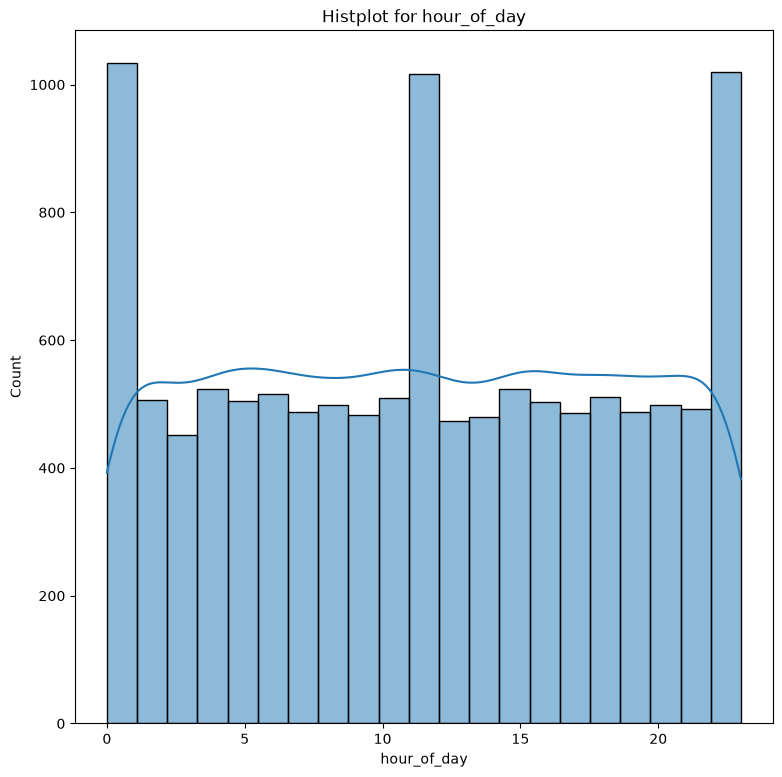

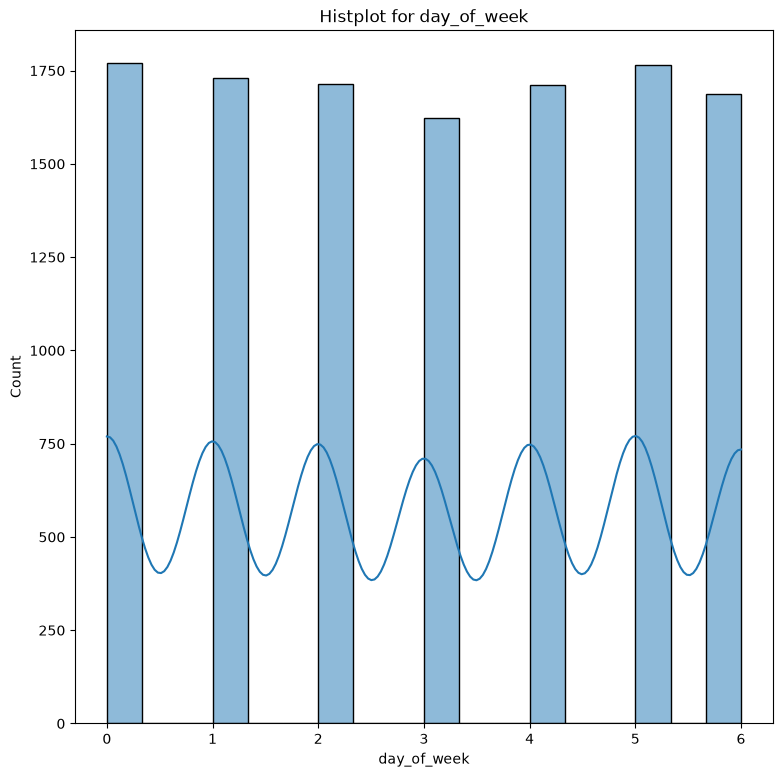

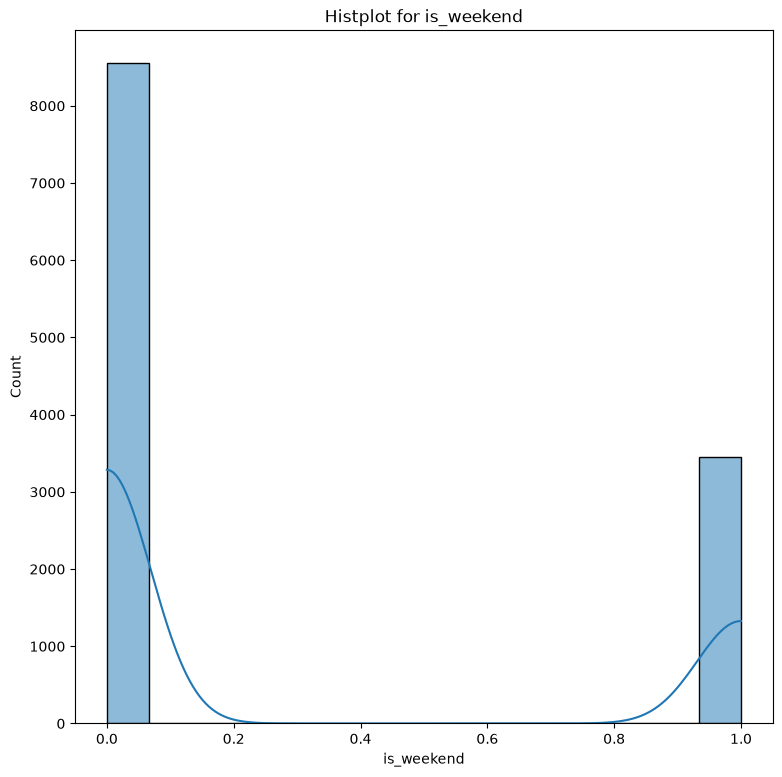

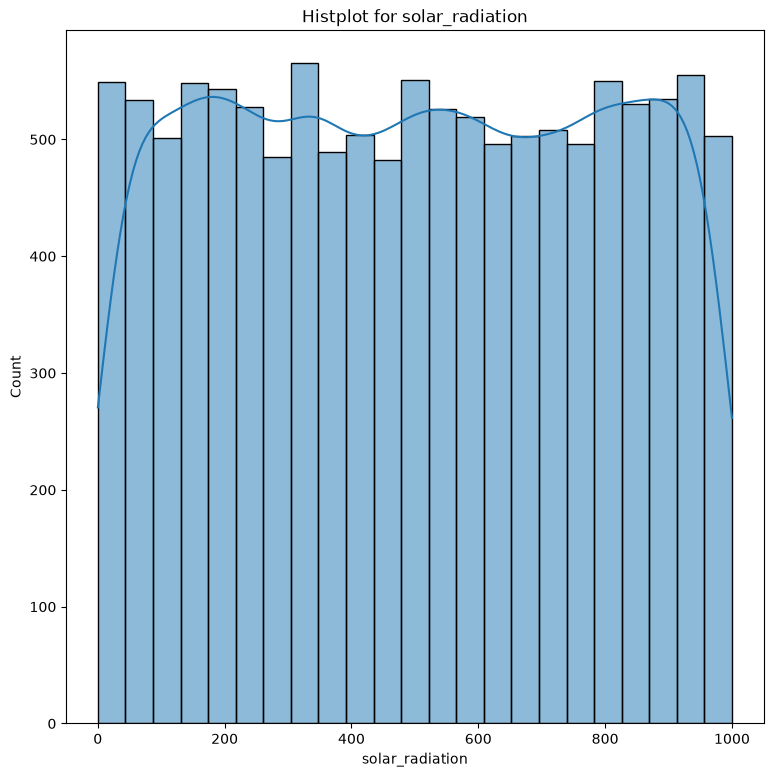

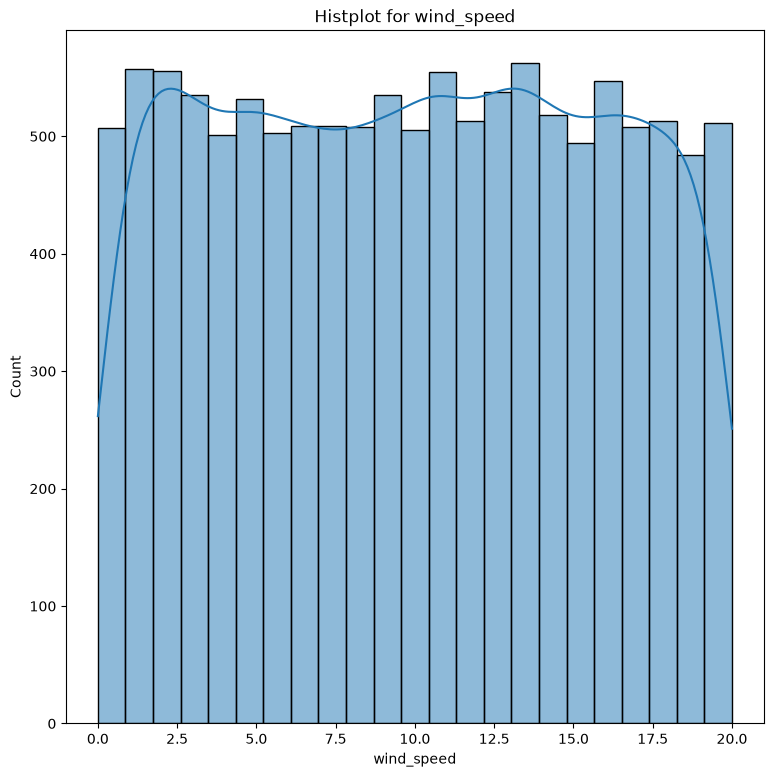

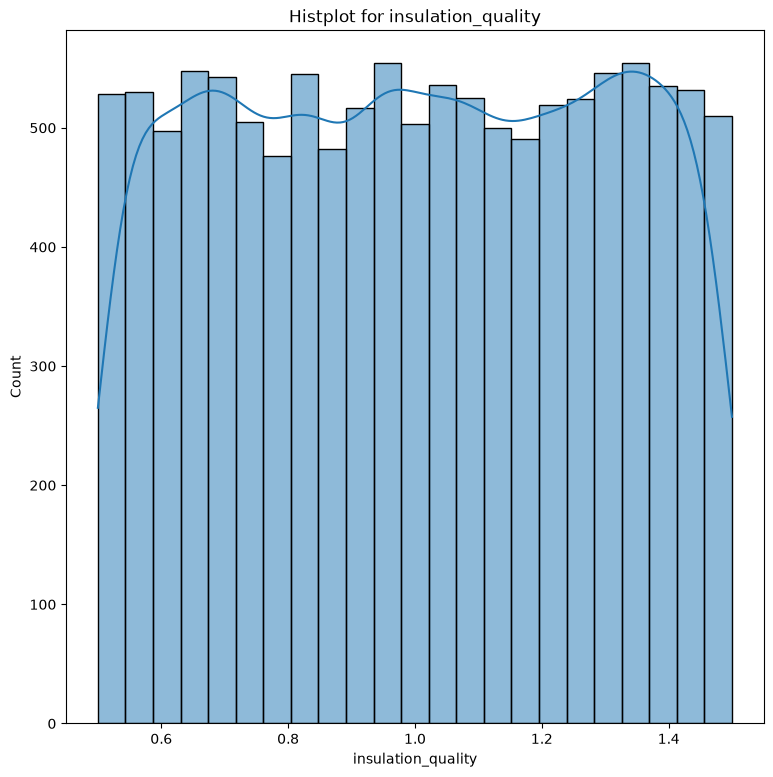

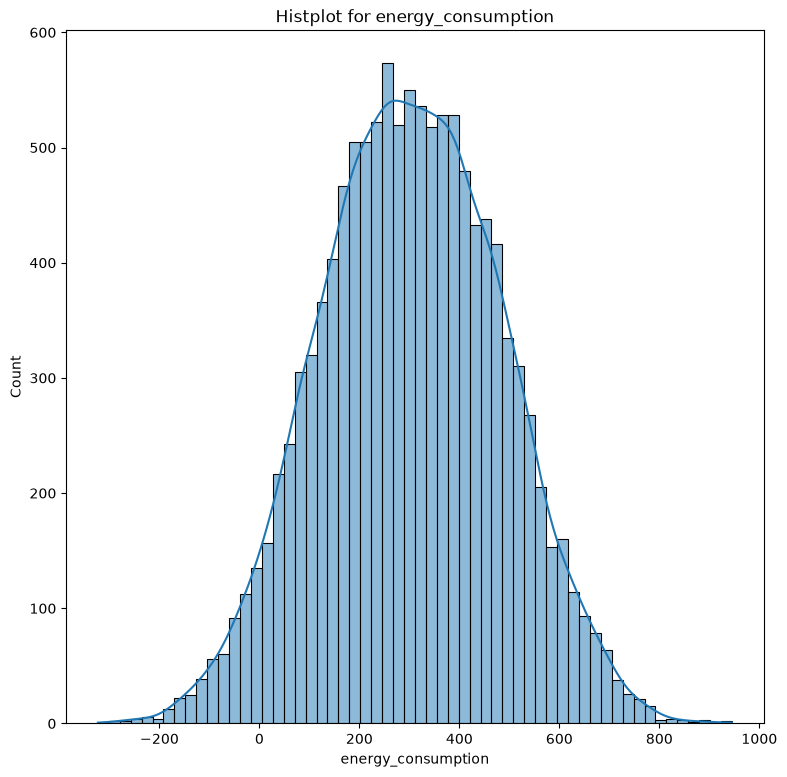

In [19]:
for col in numerical_columns:
    plt.figure(figsize=(9,9))
    sns.histplot(dfcopy[col], kde=True)
    plt.title(f"Histplot for {col}")
    plt.show()

By seeing the plot the distribution looks fairly balanced and as seen earlier there is good amount of variance in energy consumption column which is shown as outlier but is accepted logically.

Using Z-score method to cross verify the results because the distribution is balanced 

In [20]:
def zscore_series(s: pd.Series):
    s = s.dropna()
    return (s - s.mean()) / s.std(ddof=0)

In [22]:
zscore_counts = {}

for col in numerical_columns:
    z = zscore_series(dfcopy[col])
    zscore_counts[col] = int((np.abs(z) > 3).sum())

pd.DataFrame({ "Z score counts": zscore_counts })

,Z score counts
building_size,0
num_occupants,0
num_appliances,0
outside_temp,0
inside_temp,0
humidity,0
hour_of_day,0
day_of_week,0
is_weekend,0
solar_radiation,0


## 7. Correlation analysis

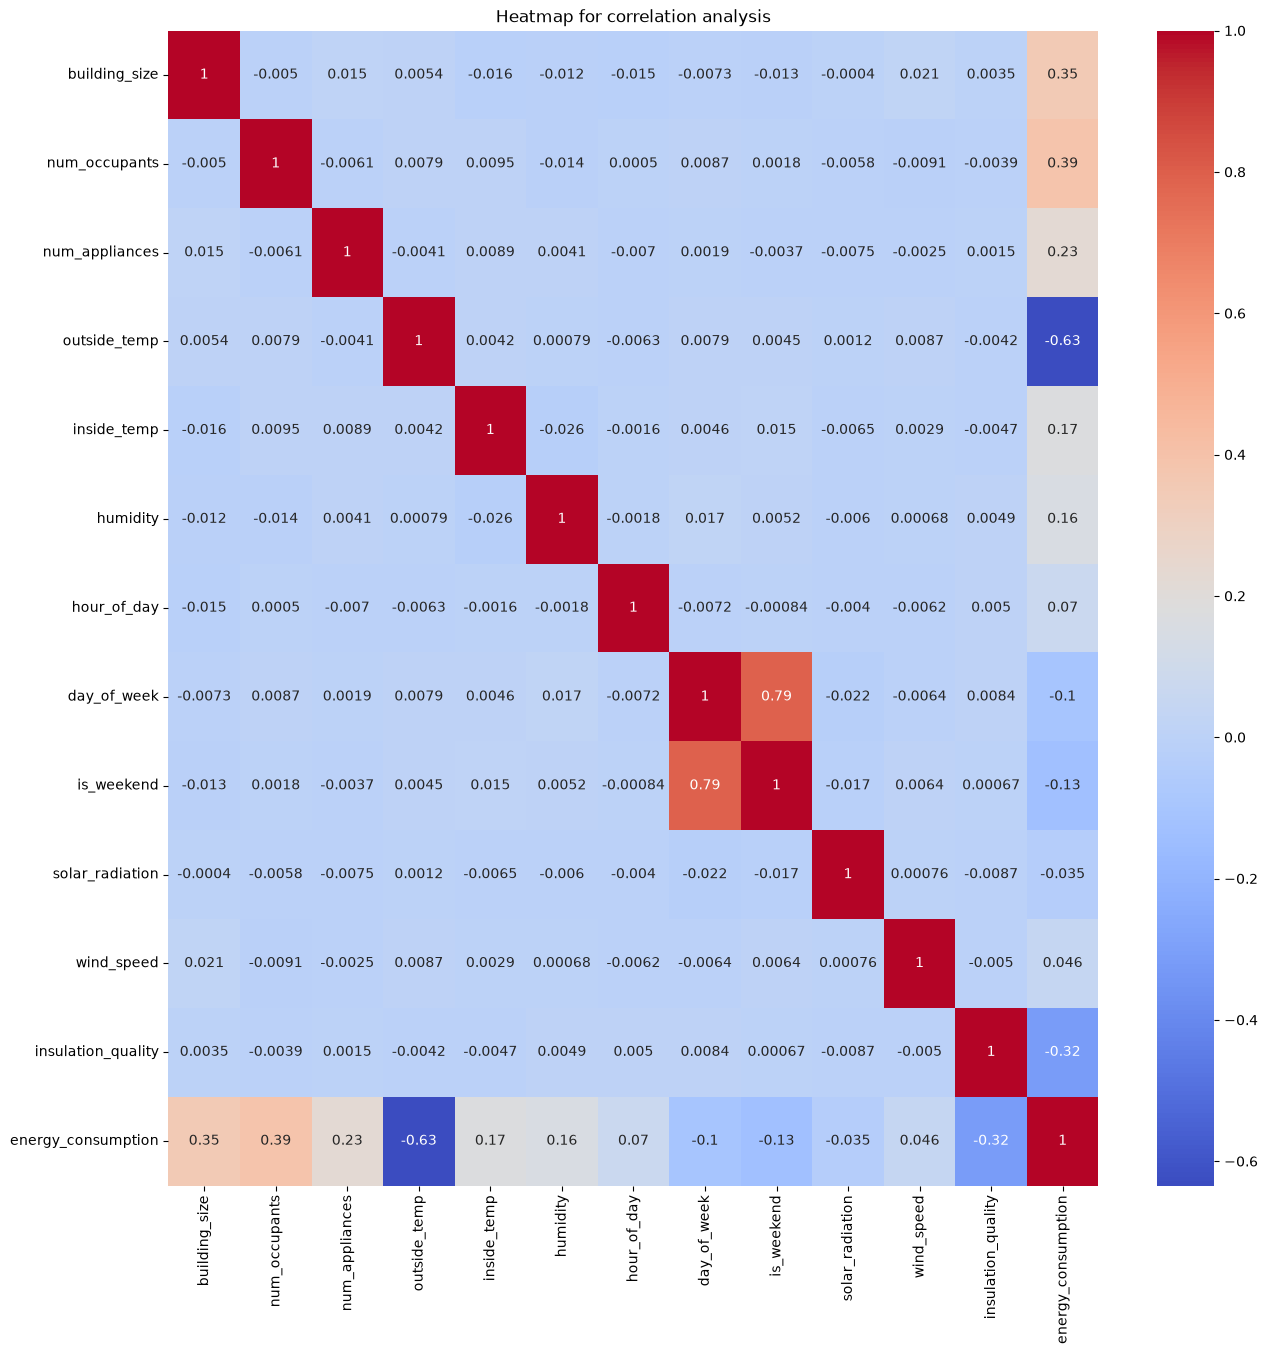

In [24]:
corr = numerical_columns.corr()

plt.figure(figsize=(15,15))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Heatmap for correlation analysis")
plt.show()

There are only 2 significant correlations present which are also logically related; rest of the ones are not viable suggesting this might be a synthetic dataset.

####  Preprocessing Decisions
✘ Can apply StandardScaler but not applied

Reason:
XGBoost is a tree-based algorithm and does not require feature scaling.

## 8. Preparing the data for model training

In [25]:
X = dfcopy.drop(columns=["energy_consumption"])
y = dfcopy["energy_consumption"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(9600, 12)
(2400, 12)
(9600,)
(2400,)


In [68]:
XGB_PARAMS = {
    "learning_rate": 0.1,
    "n_estimators": 300,
    "max_depth": 3,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": RANDOM_STATE
}

## 9. Training the model

In [69]:
model = XGBRegressor(**XGB_PARAMS)

In [71]:
model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## 10. Predicting and evaluating the model metrics

In [72]:
y_pred = model.predict(X_test)

In [ ]:
print("R2 score: ", r2_score(y_test, y_pred))

print("Mean absolute error: ", mean_absolute_error(y_test, y_pred))

print("Mean squared error: ", mean_squared_error(y_test, y_pred))

print("Root mean squared error: ", root_mean_squared_error(y_test, y_pred))

R2 score:  0.9132509358775858
Mean absolute error:  42.08940869262454
Mean squared error:  2749.1950821179216
Root mean squared error:  52.43276725596239


In [77]:
df_high_demand = pd.DataFrame({
    'building_size': [450.0, 480.0],
    'num_occupants': [45, 48],
    'num_appliances': [45, 48],
    'outside_temp': [-5.0, -8.0],
    'inside_temp': [26.0, 28.0],
    'humidity': [40.0, 35.0],
    'hour_of_day': [20, 22],        # Evening/Night
    'day_of_week': [6, 5],          # Weekend
    'is_weekend': [1, 1],
    'solar_radiation': [0.0, 0.0],  # No sun at night
    'wind_speed': [18.0, 19.0],     # High wind
    'insulation_quality': [0.6, 0.5] # Poor insulation (near minimum)
})

model_prediction = model.predict(df_high_demand)
print("Model prediction: ", model_prediction)

Model prediction:  [768.2179  835.54285]


In [78]:
df_low_demand = pd.DataFrame({
    'building_size': [80.0, 60.0],
    'num_occupants': [2, 1],
    'num_appliances': [8, 5],
    'outside_temp': [21.0, 22.0],
    'inside_temp': [21.0, 22.0],
    'humidity': [45.0, 50.0],
    'hour_of_day': [14, 15],        # Afternoon
    'day_of_week': [2, 3],          # Weekday
    'is_weekend': [0, 0],
    'solar_radiation': [600.0, 750.0], 
    'wind_speed': [2.0, 1.0],       # Low wind
    'insulation_quality': [1.4, 1.5] # Great insulation (near maximum)
})

model_prediction = model.predict(df_low_demand)
print("Model prediction: ", model_prediction)

Model prediction:  [-109.704384 -164.06744 ]


In [79]:
df_median_demand = pd.DataFrame({
    'building_size': [272.26],
    'num_occupants': [25],
    'num_appliances': [27],
    'outside_temp': [14.94],
    'inside_temp': [22.96],
    'humidity': [54.97],
    'hour_of_day': [11],
    'day_of_week': [3],
    'is_weekend': [0],
    'solar_radiation': [500.78],
    'wind_speed': [10.02],
    'insulation_quality': [1.00]
})

model_prediction = model.predict(df_median_demand)
print("Model prediction: ", model_prediction)

Model prediction:  [336.98074]


## 11. Visualization of the model output and feature importance

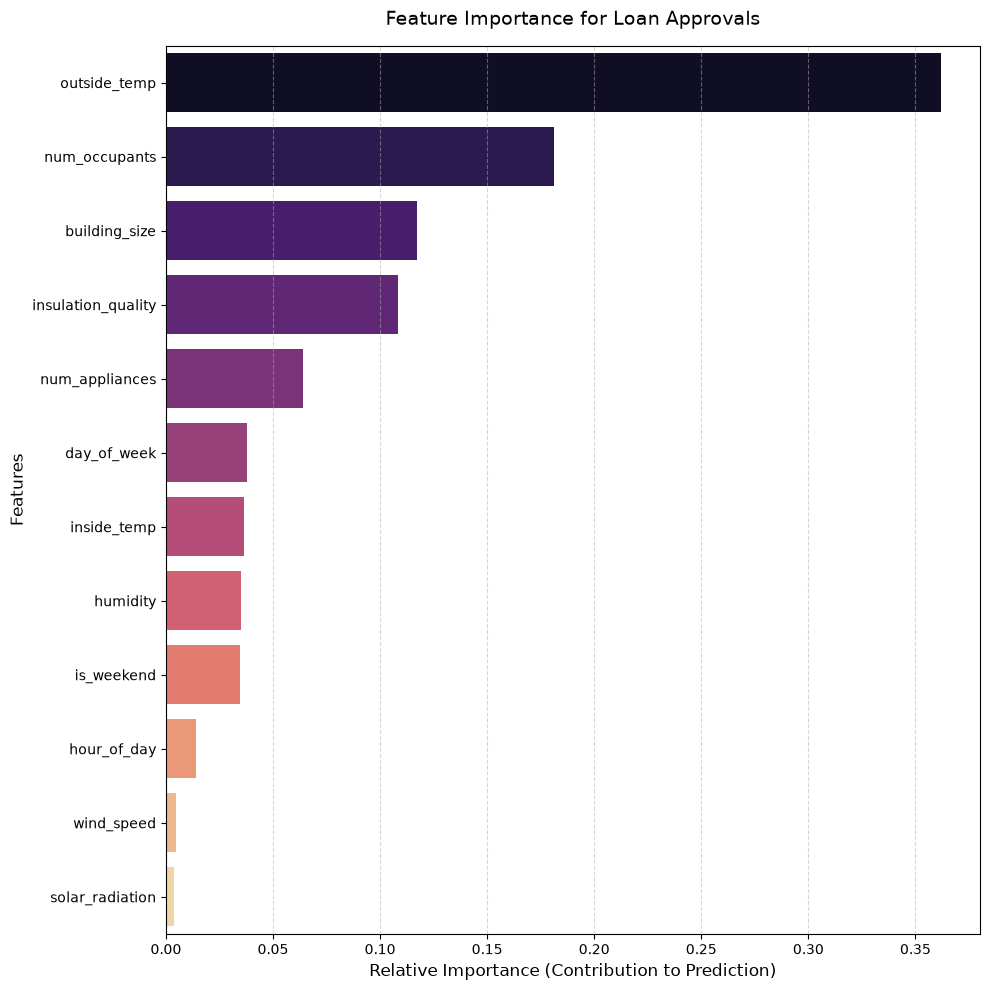

In [80]:
importances = model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=importance_df, 
    hue='Feature',
    palette='magma', 
    legend=False
)

plt.title('Feature Importance for Loan Approvals', fontsize=14, pad=15)
plt.xlabel('Relative Importance (Contribution to Prediction)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

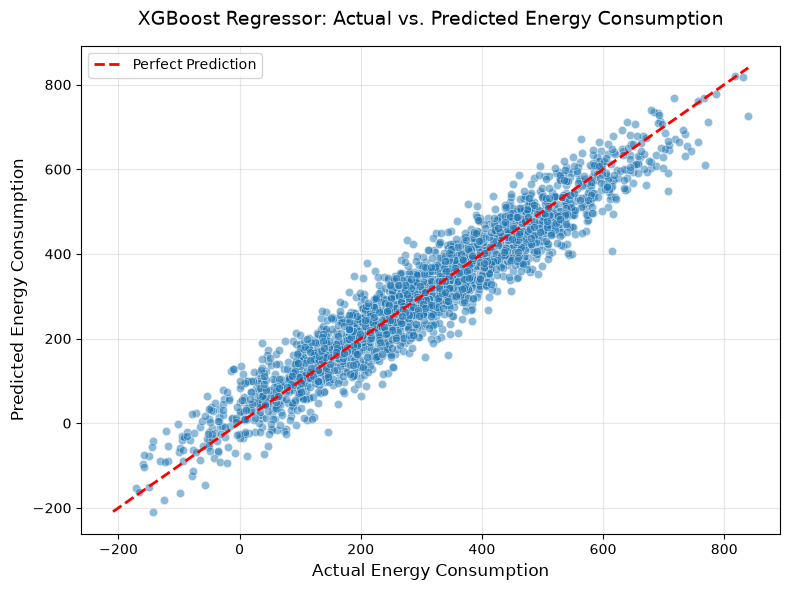

In [81]:
plt.figure(figsize=(8, 6))

# Scatter plot of actual vs predicted
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='#1f77b4')

# Perfect prediction diagonal line
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Perfect Prediction')

plt.title('XGBoost Regressor: Actual vs. Predicted Energy Consumption', fontsize=14, pad=15)
plt.xlabel('Actual Energy Consumption', fontsize=12)
plt.ylabel('Predicted Energy Consumption', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()